# BUSINESS ANALYTICS WITH PYTHON
# Apple Inc. (AAPL) Stock Price Analysis

In [16]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [17]:
# 2. UPLOAD DATASET

uploaded = files.upload()

filename = next(iter(uploaded))

print("Uploaded file:")
print(filename)

Saving AAPL_CA_verified_dataset_28May-26Aug2026.csv to AAPL_CA_verified_dataset_28May-26Aug2026.csv
Uploaded file:
AAPL_CA_verified_dataset_28May-26Aug2026.csv


In [ ]:
# 3. IMPORT DATA

df = pd.read_csv(
    filename,
    parse_dates=["Date"]
)

print("CSV loaded successfully!")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

CSV loaded successfully!
Number of rows: 63
Number of columns: 11


In [ ]:
# 4. DISPLAY FIRST FIVE ROWS

print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
        Date    Open    High     Low   Close    Volume  Daily_Return_%  \
0 2026-05-28  310.68  312.80  309.57  312.51  48220400             NaN   
1 2026-05-29  311.78  315.00  309.53  312.06  70026800       -0.143995   
2 2026-06-01  309.63  310.94  305.02  306.31  48849900       -1.842594   
3 2026-06-02  307.46  315.45  306.69  315.20  44534700        2.902289   
4 2026-06-03  314.18  316.94  308.85  310.26  50836700       -1.567259   

   Price_Range  MA_7  MA_20  Next_Close  
0         3.23   NaN    NaN      312.06  
1         5.47   NaN    NaN      306.31  
2         5.92   NaN    NaN      315.20  
3         8.76   NaN    NaN      310.26  
4         8.09   NaN    NaN      311.23  


In [ ]:
# 5. SORT DATA CHRONOLOGICALLY

df = df.sort_values("Date").reset_index(drop=True)

print("Data sorted by Date successfully!")
print(df.head())

Data sorted by Date successfully!
        Date    Open    High     Low   Close    Volume  Daily_Return_%  \
0 2026-05-28  310.68  312.80  309.57  312.51  48220400             NaN   
1 2026-05-29  311.78  315.00  309.53  312.06  70026800       -0.143995   
2 2026-06-01  309.63  310.94  305.02  306.31  48849900       -1.842594   
3 2026-06-02  307.46  315.45  306.69  315.20  44534700        2.902289   
4 2026-06-03  314.18  316.94  308.85  310.26  50836700       -1.567259   

   Price_Range  MA_7  MA_20  Next_Close  
0         3.23   NaN    NaN      312.06  
1         5.47   NaN    NaN      306.31  
2         5.92   NaN    NaN      315.20  
3         8.76   NaN    NaN      310.26  
4         8.09   NaN    NaN      311.23  


In [ ]:
# 6. REMOVE DUPLICATE TRADING DATES

df = df.drop_duplicates(
    subset="Date"
).reset_index(drop=True)

print("Duplicate dates removed successfully!")
print("Total observations:", len(df))

Duplicate dates removed successfully!
Total observations: 63


In [ ]:
# 7. CHECK MISSING VALUES

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Date               0
Open               0
High               0
Low                0
Close              0
Volume             0
Daily_Return_%     1
Price_Range        0
MA_7               6
MA_20             19
Next_Close         1
dtype: int64


In [ ]:
# 8. CONVERT NUMERIC COLUMNS

numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print("Numeric columns converted successfully!")

Numeric columns converted successfully!


In [ ]:
# 9. FEATURE ENGINEERING – DAILY RETURN

df["Daily_Return_%"] = df["Close"].pct_change() * 100

print("Daily Return created successfully!")
print(df[["Date", "Close", "Daily_Return_%"]].head(10))

Daily Return created successfully!
        Date   Close  Daily_Return_%
0 2026-05-28  312.51             NaN
1 2026-05-29  312.06       -0.143995
2 2026-06-01  306.31       -1.842594
3 2026-06-02  315.20        2.902289
4 2026-06-03  310.26       -1.567259
5 2026-06-04  311.23        0.312641
6 2026-06-05  307.34       -1.249880
7 2026-06-08  301.54       -1.887161
8 2026-06-09  290.55       -3.644624
9 2026-06-10  291.58        0.354500


In [ ]:
# 10. FEATURE ENGINEERING – PRICE RANGE

df["Price_Range"] = df["High"] - df["Low"]

print("Price Range created successfully!")
print(df[["Date", "High", "Low", "Price_Range"]].head())

Price Range created successfully!
        Date    High     Low  Price_Range
0 2026-05-28  312.80  309.57         3.23
1 2026-05-29  315.00  309.53         5.47
2 2026-06-01  310.94  305.02         5.92
3 2026-06-02  315.45  306.69         8.76
4 2026-06-03  316.94  308.85         8.09


In [ ]:
# 11. FEATURE ENGINEERING – 7-DAY MOVING AVERAGE

df["MA_7"] = df["Close"].rolling(window=7).mean()

print("7-Day Moving Average created successfully!")
print(df[["Date", "Close", "MA_7"]].head(10))

7-Day Moving Average created successfully!
        Date   Close        MA_7
0 2026-05-28  312.51         NaN
1 2026-05-29  312.06         NaN
2 2026-06-01  306.31         NaN
3 2026-06-02  315.20         NaN
4 2026-06-03  310.26         NaN
5 2026-06-04  311.23         NaN
6 2026-06-05  307.34  310.701429
7 2026-06-08  301.54  309.134286
8 2026-06-09  290.55  306.061429
9 2026-06-10  291.58  303.957143


In [ ]:
# 12. FEATURE ENGINEERING – 20-DAY MOVING AVERAGE

df["MA_20"] = df["Close"].rolling(window=20).mean()

print("20-Day Moving Average created successfully!")
print(df[["Date", "Close", "MA_20"]].head(25))

20-Day Moving Average created successfully!
         Date   Close     MA_20
0  2026-05-28  312.51       NaN
1  2026-05-29  312.06       NaN
2  2026-06-01  306.31       NaN
3  2026-06-02  315.20       NaN
4  2026-06-03  310.26       NaN
5  2026-06-04  311.23       NaN
6  2026-06-05  307.34       NaN
7  2026-06-08  301.54       NaN
8  2026-06-09  290.55       NaN
9  2026-06-10  291.58       NaN
10 2026-06-11  295.63       NaN
11 2026-06-12  291.13       NaN
12 2026-06-15  296.42       NaN
13 2026-06-16  299.24       NaN
14 2026-06-17  295.95       NaN
15 2026-06-18  298.01       NaN
16 2026-06-22  297.01       NaN
17 2026-06-23  294.30       NaN
18 2026-06-24  293.08       NaN
19 2026-06-25  275.15  299.7250
20 2026-06-26  283.78  298.2885
21 2026-06-29  281.74  296.7725
22 2026-06-30  289.36  295.9250
23 2026-07-01  294.38  294.8840
24 2026-07-02  308.63  294.8025


In [ ]:
# 13. CREATE NEXT-DAY CLOSING PRICE

df["Next_Close"] = df["Close"].shift(-1)

print("Next-Day Closing Price created successfully!")
print(df[["Date", "Close", "Next_Close"]].head(10))

Next-Day Closing Price created successfully!
        Date   Close  Next_Close
0 2026-05-28  312.51      312.06
1 2026-05-29  312.06      306.31
2 2026-06-01  306.31      315.20
3 2026-06-02  315.20      310.26
4 2026-06-03  310.26      311.23
5 2026-06-04  311.23      307.34
6 2026-06-05  307.34      301.54
7 2026-06-08  301.54      290.55
8 2026-06-09  290.55      291.58
9 2026-06-10  291.58      295.63


In [ ]:
# 14. DISPLAY FEATURE-ENGINEERED DATA

print("Feature-engineered data:")

print(
    df[
        [
            "Date",
            "Close",
            "Daily_Return_%",
            "Price_Range",
            "MA_7",
            "MA_20",
            "Next_Close"
        ]
    ].head(25)
)

Feature-engineered data:
         Date   Close  Daily_Return_%  Price_Range        MA_7     MA_20  \
0  2026-05-28  312.51             NaN         3.23         NaN       NaN   
1  2026-05-29  312.06       -0.143995         5.47         NaN       NaN   
2  2026-06-01  306.31       -1.842594         5.92         NaN       NaN   
3  2026-06-02  315.20        2.902289         8.76         NaN       NaN   
4  2026-06-03  310.26       -1.567259         8.09         NaN       NaN   
5  2026-06-04  311.23        0.312641         3.89         NaN       NaN   
6  2026-06-05  307.34       -1.249880         8.02  310.701429       NaN   
7  2026-06-08  301.54       -1.887161        16.23  309.134286       NaN   
8  2026-06-09  290.55       -3.644624        12.97  306.061429       NaN   
9  2026-06-10  291.58        0.354500         7.37  303.957143       NaN   
10 2026-06-11  295.63        1.388984         7.41  301.161429       NaN   
11 2026-06-12  291.13       -1.522173         7.52  298.428571 

In [ ]:
# 15. SUMMARY STATISTICS

summary = df[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "Daily_Return_%",
        "Price_Range"
    ]
].describe()

print("Summary Statistics:")
print(summary)

Summary Statistics:
             Open        High         Low       Close        Volume  \
count   63.000000   63.000000   63.000000   63.000000  6.300000e+01   
mean   309.166667  313.093968  305.742540  309.566190  5.568851e+07   
std     13.497684   13.403076   13.969525   14.165483  3.187427e+07   
min    275.000000  285.950000  273.750000  275.150000  2.586980e+07   
25%    300.565000  304.040000  296.190000  300.390000  4.133120e+07   
50%    309.630000  313.360000  307.000000  310.030000  4.822040e+07   
75%    314.530000  317.170000  310.695000  315.260000  6.196410e+07   
max    340.030000  344.570000  337.350000  340.080000  2.617755e+08   

       Daily_Return_%  Price_Range  
count       62.000000    63.000000  
mean         0.025441     7.351429  
std          2.034518     2.936283  
min         -7.353867     3.190000  
25%         -1.043166     5.375000  
50%          0.181758     7.200000  
75%          1.108114     8.445000  
max          4.840682    16.230000  


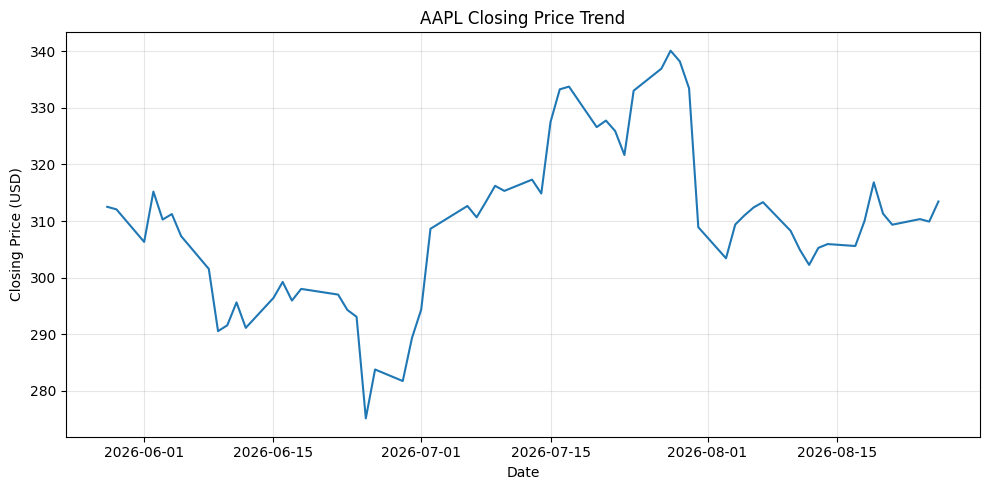

In [ ]:
# 16. GRAPH 1 – AAPL CLOSING PRICE TREND

plt.figure(figsize=(10, 5))

plt.plot(
    df["Date"],
    df["Close"]
)

plt.title("AAPL Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

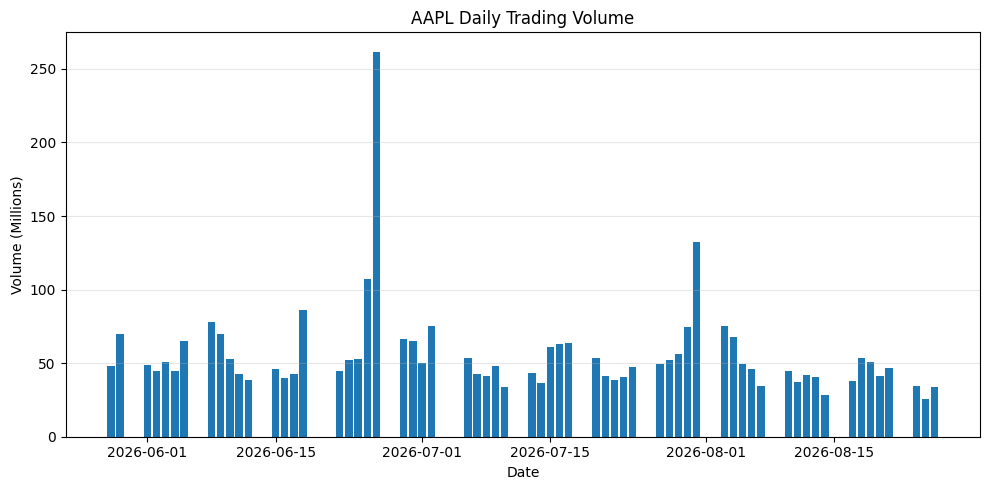

In [ ]:
# 17. GRAPH 2 – AAPL DAILY TRADING VOLUME

plt.figure(figsize=(10, 5))

plt.bar(
    df["Date"],
    df["Volume"] / 1_000_000
)

plt.title("AAPL Daily Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume (Millions)")

plt.grid(
    True,
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

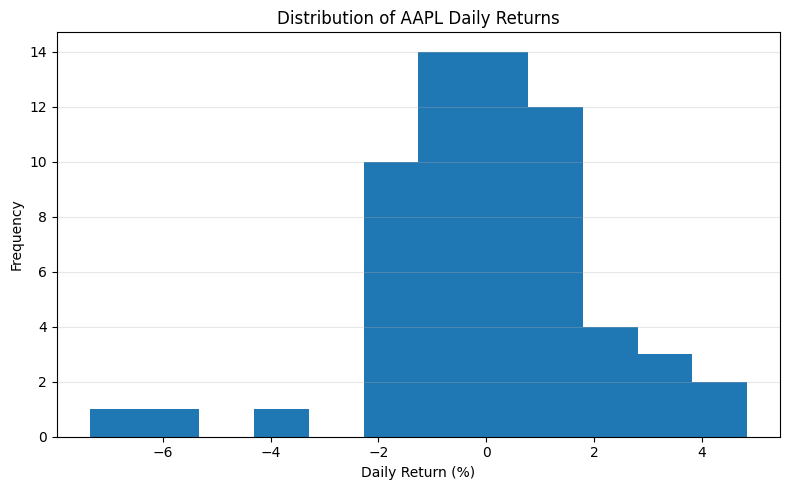

In [ ]:
# 18. GRAPH 3 – DISTRIBUTION OF DAILY RETURNS

daily_returns = pd.to_numeric(
    df["Daily_Return_%"],
    errors="coerce"
).dropna()

plt.figure(figsize=(8, 5))

plt.hist(
    daily_returns,
    bins=12
)

plt.title("Distribution of AAPL Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.grid(
    True,
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

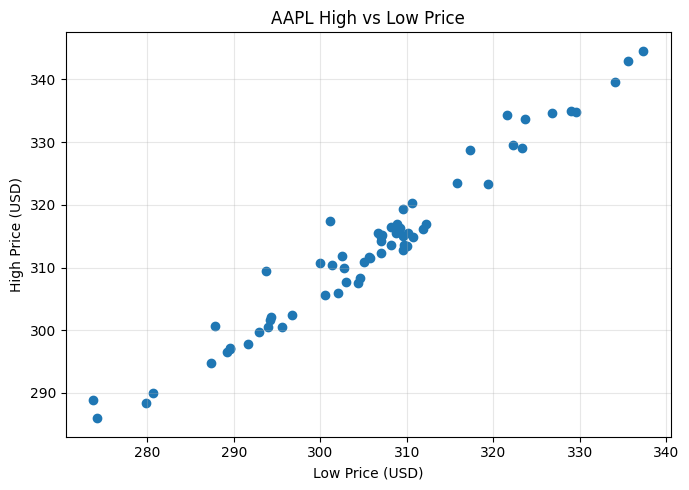

In [ ]:
# 19. GRAPH 4 – AAPL HIGH VS LOW PRICE

high_prices = pd.to_numeric(
    df["High"],
    errors="coerce"
)

low_prices = pd.to_numeric(
    df["Low"],
    errors="coerce"
)

valid_data = pd.DataFrame({
    "High": high_prices,
    "Low": low_prices
}).dropna()

plt.figure(figsize=(7, 5))

plt.scatter(
    valid_data["Low"],
    valid_data["High"]
)

plt.title("AAPL High vs Low Price")
plt.xlabel("Low Price (USD)")
plt.ylabel("High Price (USD)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

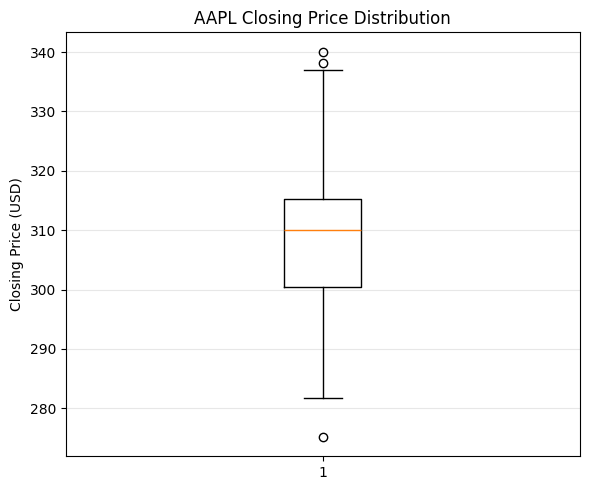

In [ ]:
# 20. GRAPH 5 – AAPL CLOSING PRICE DISTRIBUTION

close_prices = pd.to_numeric(
    df["Close"],
    errors="coerce"
).dropna()

plt.figure(figsize=(6, 5))

plt.boxplot(close_prices)

plt.title("AAPL Closing Price Distribution")
plt.ylabel("Closing Price (USD)")

plt.grid(
    True,
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

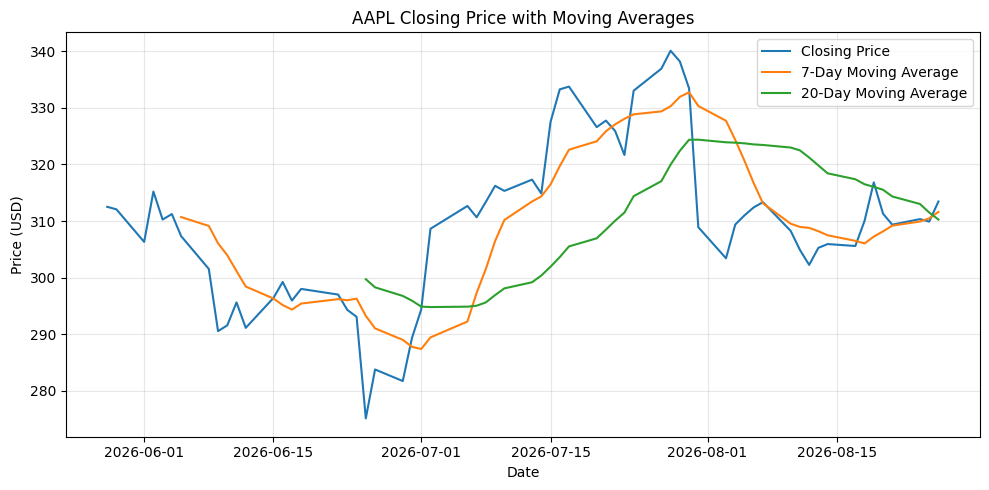

In [ ]:
# 21. GRAPH 6 – CLOSING PRICE WITH MOVING AVERAGES

plt.figure(figsize=(10, 5))

plt.plot(
    df["Date"],
    df["Close"],
    label="Closing Price"
)

plt.plot(
    df["Date"],
    df["MA_7"],
    label="7-Day Moving Average"
)

plt.plot(
    df["Date"],
    df["MA_20"],
    label="20-Day Moving Average"
)

plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 22. PREPARE DATA FOR LINEAR REGRESSION

features = [
    "Close",
    "Volume",
    "Daily_Return_%",
    "Price_Range",
    "MA_7",
    "MA_20"
]

model_data = df.dropna(
    subset=features + ["Next_Close"]
).copy()

print("Model data prepared successfully!")
print("Model observations:", len(model_data))

Model data prepared successfully!
Model observations: 43


In [ ]:
# 23. DEFINE INDEPENDENT AND DEPENDENT VARIABLES

X = model_data[features]

y = model_data["Next_Close"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (43, 6)
y shape: (43,)


In [ ]:
# 24. CHRONOLOGICAL 80:20 TRAIN-TEST SPLIT

split = int(len(model_data) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 34
Testing observations: 9


In [ ]:
# 25. CREATE AND TRAIN LINEAR REGRESSION MODEL

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
# 26. GENERATE PREDICTIONS

predictions = model.predict(X_test)

print("Predictions generated successfully!")
print(predictions)

Predictions generated successfully!
[305.89327134 306.52120923 305.55589201 308.31245395 314.49631919
 309.44352978 308.75470233 311.51704603 313.06871829]


In [ ]:
# 27. MODEL EVALUATION

mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print("============================================================")
print("MODEL EVALUATION")
print("============================================================")

print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

MODEL EVALUATION
MAE : 2.3148
MSE : 12.1037
RMSE: 3.479
R²  : -0.1349


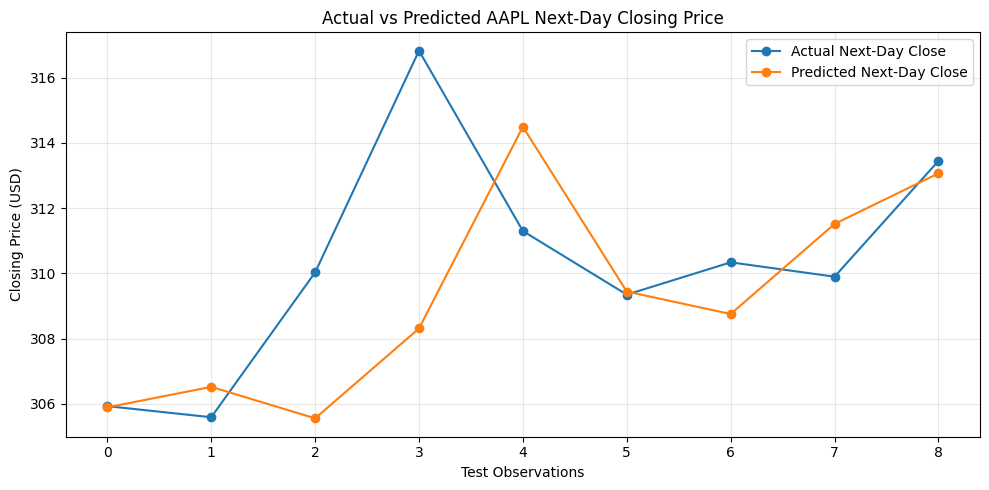

In [ ]:
# 28. GRAPH 7 – ACTUAL VS PREDICTED NEXT-DAY CLOSE

plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    marker="o",
    label="Actual Next-Day Close"
)

plt.plot(
    predictions,
    marker="o",
    label="Predicted Next-Day Close"
)

plt.title("Actual vs Predicted AAPL Next-Day Closing Price")
plt.xlabel("Test Observations")
plt.ylabel("Closing Price (USD)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
print("Length of y_test:", len(y_test))
print("Length of predictions:", len(predictions))

NameError: name 'y_test' is not defined

In [19]:
# 29. CREATE PREDICTION RESULTS TABLE

results = pd.DataFrame({
    "Actual_Next_Close": y_test.values,
    "Predicted_Next_Close": predictions
})

results["Error"] = (
    results["Actual_Next_Close"]
    - results["Predicted_Next_Close"]
)

results["Absolute_Error"] = (
    results["Error"].abs()
)

print("============================================================")
print("ACTUAL VS PREDICTED RESULTS")
print("============================================================")

print(results)

NameError: name 'y_test' is not defined

In [ ]:
# 30. MODEL COEFFICIENTS

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print("============================================================")
print("MODEL COEFFICIENTS")
print("============================================================")

print(coefficients)

print("\nIntercept:")
print(round(model.intercept_, 4))

MODEL COEFFICIENTS
          Feature   Coefficient
0           Close  4.871623e-01
1          Volume -8.836659e-08
2  Daily_Return_%  9.695331e-01
3     Price_Range  2.910417e-01
4            MA_7  4.690810e-01
5           MA_20 -3.913777e-01

Intercept:
139.2304


In [ ]:
# 31. FINAL PREDICTION TABLE

prediction_dates = model_data["Date"].iloc[split:]

final_results = pd.DataFrame({
    "Date": prediction_dates.values,
    "Actual_Next_Close": y_test.values,
    "Predicted_Next_Close": predictions
})

final_results["Error"] = (
    final_results["Actual_Next_Close"]
    - final_results["Predicted_Next_Close"]
)

final_results["Absolute_Error"] = (
    final_results["Error"].abs()
)

print("============================================================")
print("FINAL PREDICTION TABLE")
print("============================================================")

print(final_results.to_string(index=False))

FINAL PREDICTION TABLE
      Date  Actual_Next_Close  Predicted_Next_Close     Error  Absolute_Error
2026-08-13             305.93            305.893271  0.036729        0.036729
2026-08-14             305.59            306.521209 -0.931209        0.931209
2026-08-17             310.03            305.555892  4.474108        4.474108
2026-08-18             316.83            308.312454  8.517546        8.517546
2026-08-19             311.30            314.496319 -3.196319        3.196319
2026-08-20             309.35            309.443530 -0.093530        0.093530
2026-08-21             310.34            308.754702  1.585298        1.585298
2026-08-24             309.90            311.517046 -1.617046        1.617046
2026-08-25             313.45            313.068718  0.381282        0.381282


In [ ]:
# 32. FINAL PROJECT SUMMARY

print("============================================================")
print("FINAL PROJECT SUMMARY")
print("============================================================")

print("Total observations:", len(df))
print("Model observations:", len(model_data))
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nModel Performance:")
print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

print("\n============================================================")
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("============================================================")

FINAL PROJECT SUMMARY
Total observations: 63
Model observations: 43
Training observations: 34
Testing observations: 9

Model Performance:
MAE : 2.3148
MSE : 12.1037
RMSE: 3.479
R²  : -0.1349

ANALYSIS COMPLETED SUCCESSFULLY
